# MLP 生产案例集（Part 2 专属 · 含图像）

本文件针对 **makemore Part 2（MLP）** 的生产实践，和 bigram 那版**刻意做得不同**：聚焦第 2 讲最有代表性的
三件事——**学习率查找、训练曲线监控、字符嵌入可视化**，并且**每个案例都会生成图像**（已嵌入，可直接看）。

| 案例 | 场景 | 产出图像 |
|------|------|----------|
| 案例 1 | 学习率查找器（LR range test） | 📈 loss–学习率曲线 |
| 案例 2 | 训练 + 训练/验证曲线监控 | 📈 train/val loss 双曲线 |
| 案例 3 | 字符嵌入二维可视化（Part 2 招牌图） | 🔤 26 字母的 2D 散点 |
| 案例 4 | 采样温度对比 + 名字长度分布 | 📊 长度直方图 |
| 案例 5 | 保存/加载 + 困惑度评估 | —（文字指标）|

> 依赖同目录 `names.txt`。图表标签用英文以避免中文字体缺失导致乱码；讲解与注释是中文。

## 0. 通用准备

读数据、建词表、切分训练/验证集。

In [1]:
import torch                       # PyTorch 主库
import torch.nn as nn              # 神经网络模块
import torch.nn.functional as F    # 函数式接口(cross_entropy 等)
import random                      # 打乱数据
import matplotlib.pyplot as plt    # 画图
%matplotlib inline                 # 图像内嵌显示

words = open('names.txt').read().splitlines()        # 读入名字列表
chars = sorted(list(set(''.join(words))))            # 去重+排序得到所有字符
stoi = {s: i + 1 for i, s in enumerate(chars)}       # 字符->编号, 字母占 1~26
stoi['.'] = 0                                         # '.' 开始/结束符, 编号 0
itos = {i: s for s, i in stoi.items()}               # 编号->字符
vocab_size = len(itos)                               # 词表大小 = 27
block_size = 3                                        # 上下文长度: 前 3 个字符

def build_dataset(words):                            # 名字列表 -> (X, Y) 张量
    X, Y = [], []                                    # X=上下文, Y=目标
    for w in words:                                  # 遍历名字
        ctx = [0] * block_size                       # 初始上下文 [0,0,0]
        for ch in w + '.':                          # 遍历字符+结束符
            X.append(ctx); Y.append(stoi[ch])        # 记录上下文和目标
            ctx = ctx[1:] + [stoi[ch]]               # 滑动窗口
    return torch.tensor(X), torch.tensor(Y)          # 返回张量

random.seed(42); random.shuffle(words)               # 固定种子并打乱
n1 = int(0.8 * len(words)); n2 = int(0.9 * len(words))  # 80% / 90% 两个分界点
Xtr, Ytr  = build_dataset(words[:n1])                # 训练集(前80%)
Xdev,Ydev = build_dataset(words[n1:n2])              # 验证集(80%~90%)
print('训练样本:', Xtr.shape[0], ' 验证样本:', Xdev.shape[0])  # 打印数量

训练样本: 182625  验证样本: 22655


## 案例 1：学习率查找器（LR range test）

上线前先做一次**学习率扫描**：让学习率从很小(1e-3)指数增长到较大(1e0=1)，每个学习率跑一步，
记录 loss，画出「loss vs 学习率」曲线。**曲线最低点附近**就是好用的学习率——这是 Part 2 的经典调参手法。

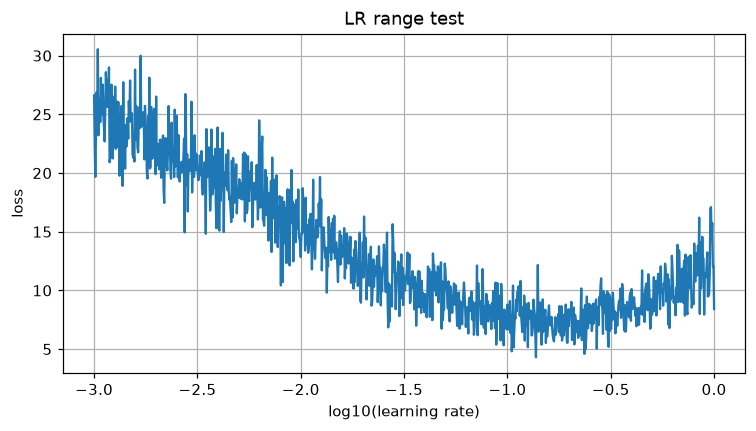

In [2]:
def init_params(n_embd=10, n_hidden=200, seed=2147483647):  # 初始化一套裸张量参数; (嵌入维10, 隐藏200)
    g = torch.Generator().manual_seed(seed)                 # 固定种子
    C  = torch.randn((vocab_size, n_embd),           generator=g)  # 嵌入表 (27, 10)
    W1 = torch.randn((n_embd * block_size, n_hidden),generator=g)  # 第一层 (30, 200)
    b1 = torch.randn(n_hidden,                       generator=g)  # 第一层偏置 (200,)
    W2 = torch.randn((n_hidden, vocab_size),         generator=g)  # 第二层 (200, 27)
    b2 = torch.randn(vocab_size,                     generator=g)  # 第二层偏置 (27,)
    params = [C, W1, b1, W2, b2]                             # 收集参数
    for p in params: p.requires_grad = True                 # 开启梯度
    return params                                           # 返回参数列表

def forward(params, Xb):                                    # 前向传播, 返回 logits
    C, W1, b1, W2, b2 = params                              # 解包参数
    emb = C[Xb]                                             # 查嵌入 (B, 3, 10)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)    # 展平(B,30)过第一层+tanh (B,200)
    return h @ W2 + b2                                      # 输出层 (B, 27)

params = init_params()                                      # 初始化参数
lre = torch.linspace(-3, 0, 1000)                           # 在[-3,0]取1000个数; (起点-3,终点0,个数1000)
lrs = 10 ** lre                                             # 学习率 = 10^lre, 即 0.001~1
lr_log, loss_log = [], []                                   # 记录 log10(学习率) 与 loss

for i in range(1000):                                       # 扫描1000个学习率, 每个跑一步
    ix = torch.randint(0, Xtr.shape[0], (32,))             # 随机抽32个样本; (0,样本数,(32,))
    loss = F.cross_entropy(forward(params, Xtr[ix]), Ytr[ix])  # 这一步的 loss
    for p in params: p.grad = None                         # 清空梯度
    loss.backward()                                        # 反向传播
    lr = lrs[i].item()                                     # 本步学习率
    for p in params: p.data += -lr * p.grad                # 用该学习率更新一步
    lr_log.append(lre[i].item()); loss_log.append(loss.item())  # 记录

plt.figure(figsize=(8, 4))                                 # 画布 (宽8, 高4)
plt.plot(lr_log, loss_log)                                 # 画 loss vs log10(学习率)
plt.xlabel('log10(learning rate)'); plt.ylabel('loss')     # 坐标轴标签(英文避免乱码)
plt.title('LR range test'); plt.grid(True)                 # 标题+网格
plt.show()                                                 # 显示(曲线最低点附近的 lr 最好)

## 案例 2：训练 + 训练/验证曲线监控

用上一步选出的合适学习率训练，并**定期记录训练集和验证集 loss**，画成双曲线。
两条线都下降说明在学习；若训练降、验证升，就是**过拟合**信号。

最终 train loss=2.3912  val loss=2.4003


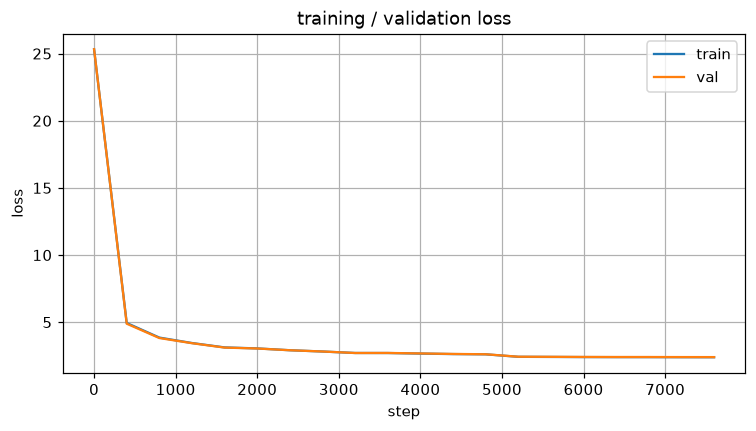

In [3]:
@torch.no_grad()                                           # 评估不追踪梯度
def full_loss(params, X, Y, batch=8192):                   # 分批算整体平均 loss; batch=8192
    tot = cnt = 0                                          # 累加
    for i in range(0, X.shape[0], batch):                 # 步长 batch 分批
        l = F.cross_entropy(forward(params, X[i:i+batch]), Y[i:i+batch], reduction='sum')  # 该批 loss 之和
        tot += l.item(); cnt += min(batch, X.shape[0]-i)  # 累加样本数
    return tot / cnt                                       # 平均 loss

params = init_params()                                     # 重新初始化一套参数
steps, tr_curve, va_curve = [], [], []                     # 记录步数/训练loss/验证loss

for i in range(8000):                                      # 训练8000步
    ix = torch.randint(0, Xtr.shape[0], (64,))            # 抽64个样本; (0,样本数,(64,))
    loss = F.cross_entropy(forward(params, Xtr[ix]), Ytr[ix])  # 这批 loss
    for p in params: p.grad = None                        # 清梯度
    loss.backward()                                       # 反向传播
    lr = 0.1 if i < 5000 else 0.01                        # 前5000步0.1, 之后0.01(衰减)
    for p in params: p.data += -lr * p.grad               # 更新
    if i % 400 == 0:                                       # 每400步记录一次
        steps.append(i)                                    # 步数
        tr_curve.append(full_loss(params, Xtr, Ytr))       # 训练集整体 loss
        va_curve.append(full_loss(params, Xdev, Ydev))     # 验证集整体 loss

plt.figure(figsize=(8, 4))                                # 画布
plt.plot(steps, tr_curve, label='train')                  # 训练曲线
plt.plot(steps, va_curve, label='val')                    # 验证曲线
plt.xlabel('step'); plt.ylabel('loss'); plt.legend()      # 轴标签+图例
plt.title('training / validation loss'); plt.grid(True)   # 标题+网格
plt.show()                                                # 显示
print('最终 train loss=%.4f  val loss=%.4f' % (tr_curve[-1], va_curve[-1]))  # 打印末尾数值

## 案例 3：字符嵌入二维可视化（Part 2 招牌图）

Part 2 最有名的图：把嵌入维度设成 **2**，训练后每个字符就是平面上一个点，
**语义相近的字符会聚在一起**（比如元音 a/e/i/o/u 常常抱团）。这是理解「嵌入学到了什么」的直观方式。

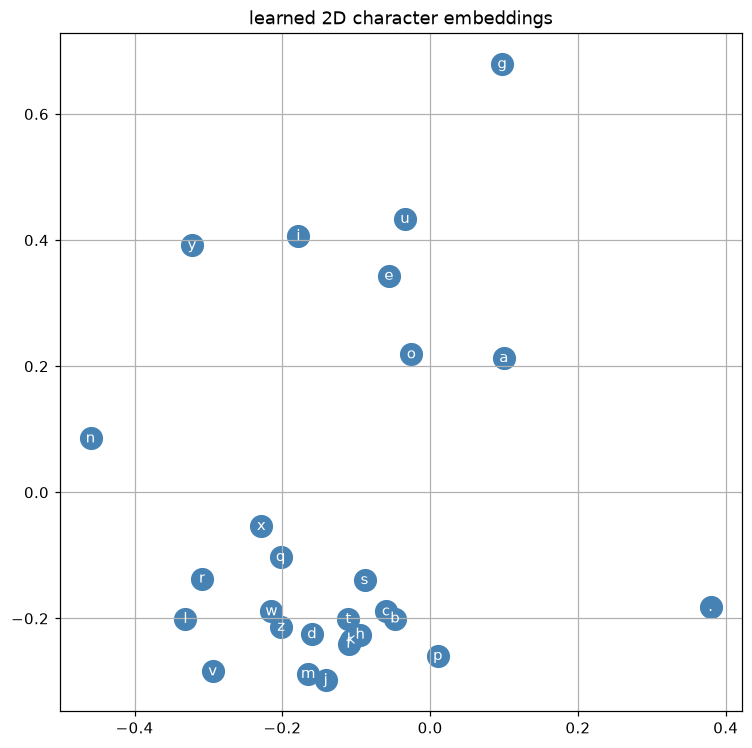

In [4]:
params2 = init_params(n_embd=2)                            # 嵌入维=2(为了能画在平面上)
for i in range(15000):                                     # 训练15000步(2维需多练会儿)
    ix = torch.randint(0, Xtr.shape[0], (64,))            # 抽64个样本
    loss = F.cross_entropy(forward(params2, Xtr[ix]), Ytr[ix])  # 这批的交叉熵 loss
    for p in params2: p.grad = None                       # 清梯度
    loss.backward()                                       # 反向传播
    lr = 0.1 if i < 10000 else 0.01                       # 分段学习率
    for p in params2: p.data += -lr * p.grad              # 更新

C2 = params2[0]                                           # 取出学好的 2 维嵌入表 (27, 2)
plt.figure(figsize=(8, 8))                                # 正方形画布
plt.scatter(C2[:, 0].data, C2[:, 1].data, s=200, color='steelblue')  # 画点; C2[:,0]横坐标, C2[:,1]纵坐标, s=200点大小
for i in range(C2.shape[0]):                              # 遍历27个字符
    plt.text(C2[i,0].item(), C2[i,1].item(), itos[i],     # 在每个点位置标注字符
             ha='center', va='center', color='white')     # 居中显示, 白色字
plt.title('learned 2D character embeddings'); plt.grid(True)  # 标题+网格
plt.show()                                                # 显示(观察元音是否聚集)

## 案例 4：采样温度对比 + 名字长度分布

生产里生成文本要**可控**。这里用不同**温度**各生成一批名字，打印示例，并画出各温度下**名字长度的分布直方图**：
温度越高越随机，长度分布通常更分散。

温度=0.5: ['marconeka', 'jaimaniel', 'rah', 'talela', 'ramarya']
温度=1.0: ['marconika', 'jalynniel', 'ralaiallya', 'ramaytz', 'larham']
温度=1.5: ['phoconika', 'inlynviet', 'wradipavlo', 'reonytz', 'lmiham']


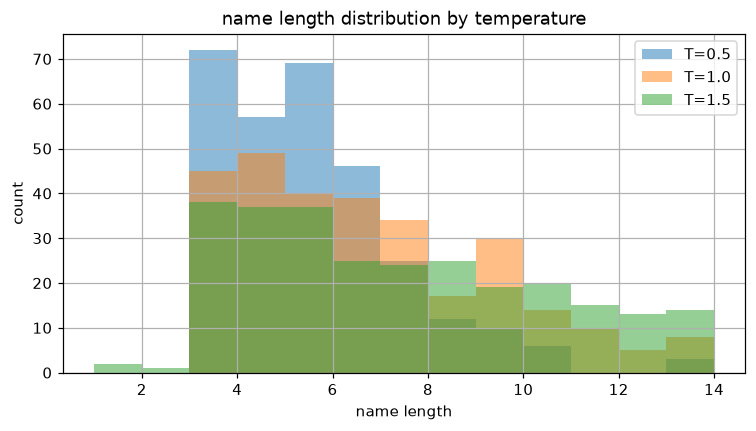

In [5]:
@torch.no_grad()                                          # 推理不追踪梯度
def sample(params, n=300, temperature=1.0, seed=0):       # 生成 n 个名字; temperature=温度
    g = torch.Generator().manual_seed(seed)               # 固定种子
    names = []                                             # 存结果
    for _ in range(n):                                     # 生成 n 个
        ctx = [0]*block_size; out = []                     # 初始上下文 + 输出
        while True:                                        # 采样到结束
            logits = forward(params, torch.tensor([ctx])) / temperature  # 前向再除温度
            p = F.softmax(logits, dim=1)                   # 转概率; dim=1沿字符维
            ix = torch.multinomial(p, 1, generator=g).item()  # 抽1个字符
            if ix == 0: break                              # 抽到'.'结束
            out.append(ix); ctx = ctx[1:] + [ix]           # 记录并滑动
        names.append(''.join(itos[i] for i in out))        # 拼成字符串
    return names                                           # 返回列表

temps = [0.5, 1.0, 1.5]                                   # 三个温度
batches = {t: sample(params, 300, t, seed=7) for t in temps}  # 每个温度各生成300个
for t in temps:                                            # 打印每个温度的前5个示例
    print(f'温度={t}:', batches[t][:5])                    # 示例

plt.figure(figsize=(8, 4))                                # 画布
for t in temps:                                            # 每个温度画一条长度分布
    lens = [len(nm) for nm in batches[t]]                 # 该温度下所有名字长度
    plt.hist(lens, bins=range(1, 15), alpha=0.5, label=f'T={t}')  # 直方图; bins=1~14, alpha半透明
plt.xlabel('name length'); plt.ylabel('count'); plt.legend()  # 轴标签+图例
plt.title('name length distribution by temperature'); plt.grid(True)  # 标题+网格
plt.show()                                                # 显示

## 案例 5：保存 / 加载 + 困惑度评估

保存**参数 + 词表 + 超参**；加载后计算**困惑度 perplexity = exp(loss)**（越低越好，比 loss 更直观）。

In [6]:
import math                                               # 用 exp
CKPT = 'mlp_params.pt'                                    # 文件名
torch.save({                                             # 保存字典
    'params': [p.detach() for p in params],              # 参数(去掉梯度信息)
    'stoi': stoi, 'itos': itos,                           # 词表
    'vocab_size': vocab_size, 'block_size': block_size,   # 超参
}, CKPT)                                                  # 写入
print('已保存到', CKPT)                                   # 提示

ckpt = torch.load(CKPT, weights_only=False)              # 读取(weights_only=False 允许载入字典对象)
loaded = ckpt['params']                                   # 取回参数
val = full_loss(loaded, Xdev, Ydev)                       # 验证集平均 loss
print(f'验证集 loss={val:.4f}  perplexity={math.exp(val):.2f}')  # 困惑度=e^loss

已保存到 mlp_params.pt
验证集 loss=2.4046  perplexity=11.07


## 小结：和 bigram 生产版的区别

这一版**专门针对 MLP（Part 2）**，重点是**可视化驱动的调参与分析**：
1. **学习率查找器** —— 上线前先扫一遍找到好用的 lr。
2. **train/val 双曲线** —— 监控收敛与过拟合。
3. **二维嵌入散点图** —— 看模型到底学到了什么（元音聚类是经典现象）。
4. **长度分布直方图** —— 量化不同温度对生成的影响。

再进阶：把裸张量换成 `nn.Module`、加 `nn.BatchNorm1d`/`nn.Dropout`、用 `torch.optim.AdamW` + 学习率调度器，
就是 Part 3/4/5（BatchNorm、Backprop Ninja、WaveNet）的方向了。
